# Ejercicio 2: Análisis del valor de las acciones de Nvidia a través del tiempo

### ¿Qué vamos a hacer?

Este notebook demuestra análisis técnico práctico de acciones de NVIDIA utilizando datos históricos reales. Aprenderás a transformar datos financieros en insights accionables mediante diversas técnicas.

1. Explorar el dataset completo de precios `OHLC` y `volumen`.
2. Calcular `retornos diarios` y `mensuales`.
3. Aplicar indicadores técnicos:
    * `Medias móviles`
    * `Volatilidad` (True Range)
    * Relación `precio-volumen`
4. Identificar `patrones` y `tendencias relevantes`.
5. Visualizar resultados con `gráficos` profesionales.
  
**Herramientas utilizadas:**

* **pandas** para manipulación de datos.
* **numpy** para cálculos matemáticos.
* **matplotlib** para visualizaciones.

### 1. Análisis

* Podemos ver que este dataframe tiene un registro de de las acciones de Nvidia, en esta ocasión corresponden a 6636 registros.
* Tenemos 6 columnas: `'Date', 'Close', 'High', 'Low', 'Open', 'Volume'`
* Corresponde a un registro histórico del comportamiento de una acción en la bolsa, donde cada fila representa lo que ocurrió en un día específico.
  - `Date (Fecha)`: Es el día específico al que corresponde la información de esa fila. Por ejemplo: 2025-10-15.
  - `Open (Apertura)`: Es el precio al que se empezó a negociar la acción ese día, es decir, cuando abrió el mercado bursátil. Si Open = 102.50, significa que ese día la primera operación se hizo a $102.50.
  - `High (Máximo)`: Es el precio más alto al que se vendió la acción durante ese día.
  - `Low (Mínimo)`: Es el precio más bajo al que se vendió la acción durante ese día.
  - `Close (Cierre)`: Es el precio final de la acción cuando cerró el mercado ese día. Este valor es muy usado para análisis porque resume cómo terminó el día. `Ojo`: No es necesariamente el último precio que alguien pagó, pero suele ser una media ponderada del final del día o el último precio real.
  - `Volume (Volumen)`: Es el número total de acciones que se compraron y vendieron ese día. Este dato da una idea de cuánta actividad hubo. Por ejemplo: Volume = 3,200,000 significa que se intercambiaron 3.2 millones de acciones ese día.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Nvidia_stock_data.csv")

### Caracterisiticas Generales
print("\n", df.columns)
print(f'Dataset --> [Filas: {df.shape[0]}], [Columnas: {df.shape[1]}]')

### Información general
print("\n", df.info())


 Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
Dataset --> [Filas: 6637], [Columnas: 6]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6637 entries, 0 to 6636
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6637 non-null   object 
 1   Close   6637 non-null   float64
 2   High    6637 non-null   float64
 3   Low     6637 non-null   float64
 4   Open    6637 non-null   float64
 5   Volume  6637 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 311.2+ KB

 None


### Precio de Cierre - El Indicador Más Importante

**Por qué es crucial:**
1. **Decisiones reales:** Instituciones y fondos usan el cierre para valorar sus activos
2. **Señales confiables:** Las rupturas de soporte/resistencia solo se confirman al cierre
3. **Backtesting:** 95% de estrategias automatizadas se basan en precios de cierre

***NOTAS***
* `pd.to_datetime()` transforma strings o números en objetos de fecha/hora que Python puede entender.
* `df[df['Date'].dt.year >= 2010]`: extrae el año de cada fecha ***>= 2010*** crea una máscara booleana (True/False) para filtrar las filas.
* `df[condición]`: Es la forma de filtrar filas en pandas. Solo conserva las filas donde la condición sea True.
* `plt.legend() `: muestra los colores de las lineas.
* `plt.grid()`: Agrega una cuadrícula para facilitar la lectura de valores.

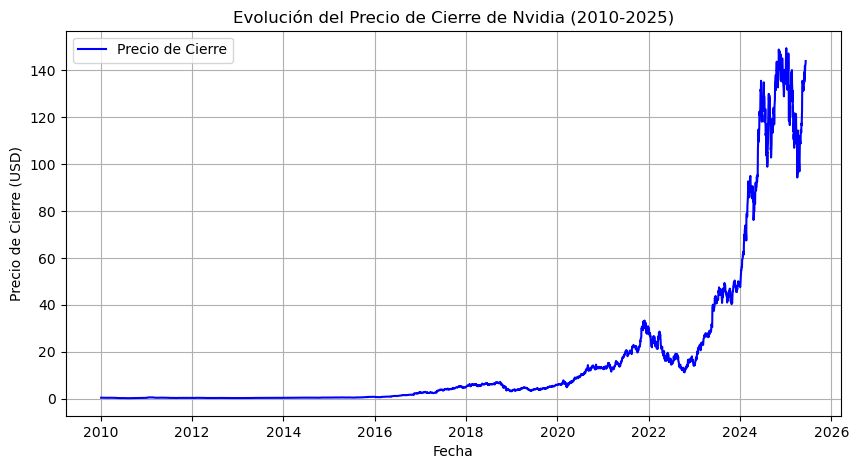

In [6]:
import matplotlib.pyplot as plt

### Convertir la columna 'Date' a formato datetime
df['Date'] = pd.to_datetime(df['Date'])

### Filtramos el DataFrame para conservar solo los datos desde el año 2010 en adelante
df_filtered = df[df['Date'].dt.year >= 2010]

### 10 pulgadas de ancho × 5 pulgadas de alto
plt.figure(figsize=(10, 5))

#### Creación de la gráfica de cierre
plt.plot(
    df_filtered['Date'],
    df_filtered['Close'],
    label='Precio de Cierre',
    color='blue'
)

# PERSONALIZACIÓN Y ELEMENTOS DEL GRÁFICO
plt.title('Evolución del Precio de Cierre de Nvidia (2010-2025)')
plt.xlabel('Fecha')            
plt.ylabel('Precio de Cierre (USD)')
plt.legend()                     
plt.grid()                      
plt.show()                      

### Volumen - El Combustible del Mercado

**Por qué importa:**
1. **Confirma tendencias:** Precio + Volumen = Señal confiable
2. **Liquidez real:** Alto volumen permite entrar/salir sin deslizamiento de precios
3. **Participación institucional:** Grandes movimientos requieren alto volumen

***NOTAS***
* `.groupby('Year')`: agrupa todas las filas que comparten el mismo año.
* `['Volume'].sum()`: suma todos los valores de volumen dentro de cada grupo anual.
* Usamos el método `.plot()` de pandas directamente sobre la serie annual_volume, esto devuelve un objeto Series de pandas.
* Las Series pueden usar .plot() directamente Pandas internamente utiliza matplotlib para hacer gráficos.También funciona para DF.
* `plt.grid(axis='y')`: Cuadrícula solo en el eje Y para facilitar lectura vertical.

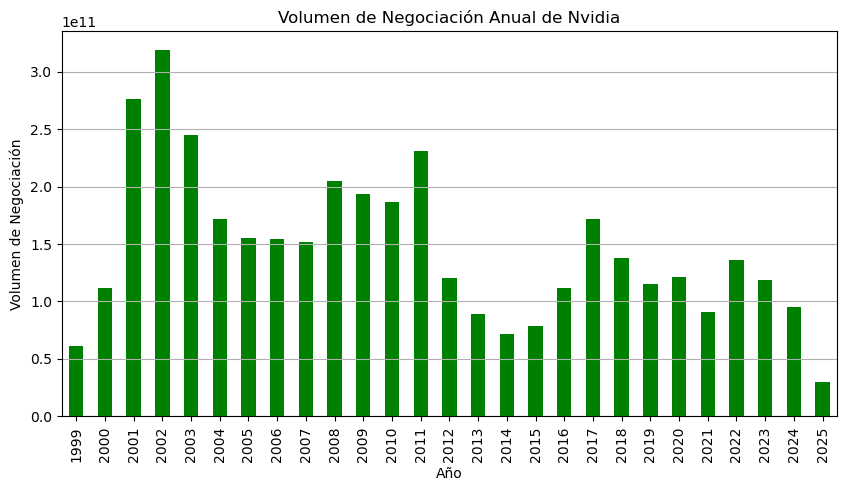

In [8]:
### Extraemos el año de la columna de fecha para agrupar los datos por año
df['Year'] = df['Date'].dt.year

### Agrupamos los datos por año y sumamos el volumen de negociación de cada año
annual_volume = df.groupby('Year')['Volume'].sum()

plt.figure(figsize=(10, 5))

annual_volume.plot(
    kind='bar',   # Tipo de gráfico: barras verticales
    color='green' # Color uniforme para todas las barras
)

# PERSONALIZACIÓN DEL GRÁFICO
plt.title('Volumen de Negociación Anual de Nvidia')  # Título descriptivo
plt.xlabel('Año')              # Etiqueta del eje X (años)
plt.ylabel('Volumen de Negociación')  # Etiqueta del eje Y (unidades de volumen)
plt.grid(axis='y')             # Cuadrícula solo en el eje Y para facilitar lectura vertical
plt.show()                     # Mostrar el gráfico

### Máximos y Mínimos - Los Límites del Mercado

**Por qué es vital:**
1. **Define el rango diario:** Donde compradores y vendedores se enfrentan
2. **Identifica volatilidad:** Rangos amplios = mayor incertidumbre
3. **Soporte y resistencia:** Los extremos revelan niveles psicológicos clave

***NOTAS***
* `.reset_index()`: convierte 'Year' y 'Month' de índices a columnas normales.

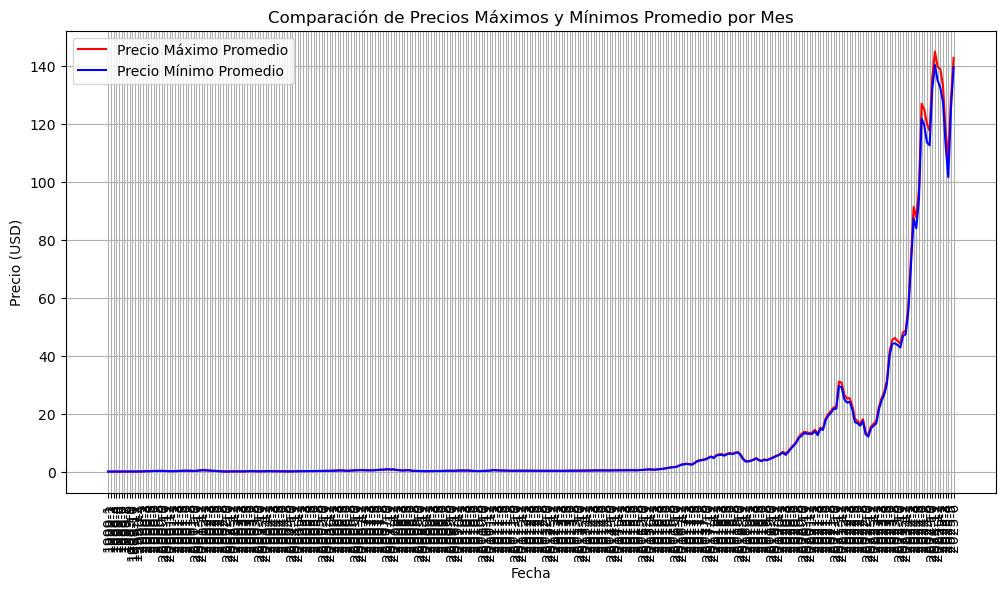

In [9]:
### Extraemos el mes y año de la fecha para agrupar a nivel mensual
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

### Agrupamos por año y mes, luego calculamos el promedio de precios máximos y mínimos
monthly_avg = df.groupby(['Year', 'Month']).agg({
    'High': 'mean',  # Calcula el promedio del precio máximo diario de cada mes
    'Low': 'mean'    # Calcula el promedio del precio mínimo diario de cada mes
}).reset_index()

plt.figure(figsize=(12, 6))

# CREACIÓN DE LAS SERIES TEMPORALES
# Primera línea: Precios máximos promedio
plt.plot(
    monthly_avg['Year'].astype(str) + '-' + monthly_avg['Month'].astype(str),  # Crear etiquetas "Año-Mes"
    monthly_avg['High'],              # Valores del eje Y (precios máximos promedio)
    label='Precio Máximo Promedio',   # Etiqueta para la leyenda
    color='red'                       # Color rojo típico para máximos/alzas
)

# Segunda línea: Precios mínimos promedio
plt.plot(
    monthly_avg['Year'].astype(str) + '-' + monthly_avg['Month'].astype(str),  # Mismas etiquetas en eje X
    monthly_avg['Low'],               # Valores del eje Y (precios mínimos promedio)
    label='Precio Mínimo Promedio',   # Etiqueta para la leyenda
    color='blue'                      # Color azul típico para mínimos/bajas
)

# PERSONALIZACIÓN AVANZADA DEL GRÁFICO
plt.title('Comparación de Precios Máximos y Mínimos Promedio por Mes')  # Título descriptivo
plt.xlabel('Fecha')              # Etiqueta del eje X (períodos mensuales)
plt.ylabel('Precio (USD)')       # Etiqueta del eje Y con unidad monetaria
plt.legend()                     # Muestra leyenda con ambas series
plt.xticks(rotation=90)          # Rota las etiquetas del eje X 90° para mejor legibilidad
plt.grid()                       # Agrega cuadrícula para facilitar lectura de valores
plt.show()                       # Renderiza y muestra el gráfico

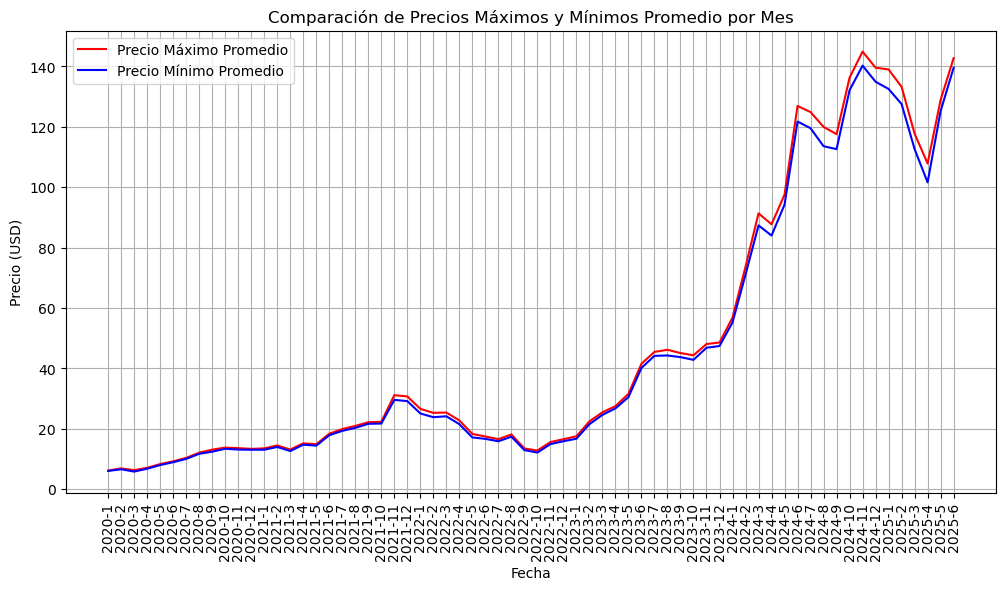

In [10]:
# CREACIÓN DE VARIABLES TEMPORALES
# Extraemos el mes y año de la fecha para agrupar a nivel mensual
df['Month'] = df['Date'].dt.month  # Extrae el número del mes (1-12)
df['Year'] = df['Date'].dt.year    # Extrae el año (ej: 2020, 2021, etc.)

# AGRUPACIÓN Y CÁLCULO DE PROMEDIOS MENSUALES CON FILTRO TEMPORAL
# Filtramos datos desde 2020 y calculamos promedios mensuales
monthly_avg = (df[df['Year'] >= 2020]      # Filtro: solo datos desde el año 2020
               .groupby(['Year', 'Month'])  # Agrupar por año y mes
               .agg({
                   'High': 'mean',  # Promedio del precio máximo diario
                   'Low': 'mean'    # Promedio del precio mínimo diario
               })
               .reset_index())      # Convertir índices a columnas normales

# CONFIGURACIÓN DEL LIENZO
plt.figure(figsize=(12, 6))  # Figura ancha para acomodar etiquetas mensuales

# CREACIÓN DE LAS SERIES TEMPORALES
# Primera línea: Precios máximos promedio
plt.plot(
    monthly_avg['Year'].astype(str) + '-' + monthly_avg['Month'].astype(str),  # Crear etiquetas "Año-Mes"
    monthly_avg['High'],              # Valores del eje Y (precios máximos promedio)
    label='Precio Máximo Promedio',   # Etiqueta para la leyenda
    color='red'                       # Color rojo para máximos
)

# Segunda línea: Precios mínimos promedio
plt.plot(
    monthly_avg['Year'].astype(str) + '-' + monthly_avg['Month'].astype(str),  # Mismas etiquetas en eje X
    monthly_avg['Low'],               # Valores del eje Y (precios mínimos promedio)
    label='Precio Mínimo Promedio',   # Etiqueta para la leyenda
    color='blue'                      # Color azul para mínimos
)

# PERSONALIZACIÓN AVANZADA DEL GRÁFICO
plt.title('Comparación de Precios Máximos y Mínimos Promedio por Mes')  # Título descriptivo
plt.xlabel('Fecha')              # Etiqueta del eje X (períodos mensuales)
plt.ylabel('Precio (USD)')       # Etiqueta del eje Y con unidad monetaria
plt.legend()                     # Muestra leyenda con ambas series
plt.xticks(rotation=90)          # Rota etiquetas del eje X 90° para mejor legibilidad
plt.grid()                       # Agrega cuadrícula para facilitar lectura
plt.show()                       # Renderiza y muestra el gráfico